In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType
import sys
import os

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

spark = SparkSession.builder \
    .appName("KMeansCafe") \
    .master("local[*]") \
    .config("spark.pyspark.python", sys.executable) \
    .config("spark.driver.host", "127.0.0.1") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

In [2]:
import glob
import pandas as pd
from functools import reduce
import os
import geopandas as gpd

pasta_arabica = 'dados-brutos/arabica'
pasta_canephora = 'dados-brutos/canephora'

arquivos_arabica = glob.glob(os.path.join(pasta_arabica, '*.xlsx'))
arquivos_canephora = glob.glob(os.path.join(pasta_canephora, '*.xlsx'))

In [3]:
def trata_excel(caminho):
    
    df = pd.read_excel(caminho, header=None)
    
    linha1 = df.iloc[1]  # variável
    linha3 = df.iloc[3]  # ano
    linha4 = df.iloc[4]  # tipo
    
    linha1 = linha1.ffill()
    linha3 = linha3.ffill()
    linha4 = linha4.ffill()
    
    novas_colunas = [
        f"{nome}_{ano}_{tipo}" if pd.notna(ano) else nome
        for nome, ano, tipo in zip(linha1, linha3, linha4)
    ]
    
    df.columns = novas_colunas
    
    df = df.iloc[5:].reset_index(drop=True)
    
    df.rename(columns={df.columns[0]: 'mesorregiao'}, inplace=True)
    
    df = df.dropna(how='all')
    
    df_long = df.melt(
        id_vars=['mesorregiao'],
        var_name='variavel_ano_tipo',
        value_name='valor'
    )
    
    df_long[['variavel', 'ano', 'tipo']] = df_long['variavel_ano_tipo'].str.rsplit('_', n=2, expand=True)
    
    df_long = df_long.drop(columns=['variavel_ano_tipo'])
    df_long['valor'] = pd.to_numeric(df_long['valor'], errors='coerce')


    df_final = df_long.pivot_table(
        index=['mesorregiao', 'ano', 'tipo'],
        columns='variavel',
        values='valor'
    ).reset_index()
    
    return df_final

In [4]:
dfs_arabica = []

for arquivo in arquivos_arabica:
    
    try:
        df = trata_excel(arquivo)
        
        dfs_arabica.append(df)
        
    except Exception as e:
        print(f"Erro em {arquivo}: {e}")

dfs_canephora = []

for arquivo in arquivos_canephora:
    
    try:
        df = trata_excel(arquivo)
        
        dfs_canephora.append(df)
        
    except Exception as e:
        print(f"Erro em {arquivo}: {e}")

In [5]:
dfs_arabica[0]

variavel,mesorregiao,ano,tipo,Variável - Área colhida (Hectares)
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,2.0
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,2733.0
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,2615.0
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,2549.0
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,2265.0
...,...,...,...,...
819,Zona da Mata (MG),2020,Café (em grão) Arábica,202022.0
820,Zona da Mata (MG),2021,Café (em grão) Arábica,190782.0
821,Zona da Mata (MG),2022,Café (em grão) Arábica,202730.0
822,Zona da Mata (MG),2023,Café (em grão) Arábica,201832.0


In [6]:
dfs_canephora[0]

variavel,mesorregiao,ano,tipo,Variável - Área colhida (Hectares)
0,Baixo Amazonas (PA),2012,Café (em grão) Canephora,255.0
1,Baixo Amazonas (PA),2013,Café (em grão) Canephora,213.0
2,Baixo Amazonas (PA),2014,Café (em grão) Canephora,138.0
3,Baixo Amazonas (PA),2015,Café (em grão) Canephora,56.0
4,Baixo Amazonas (PA),2016,Café (em grão) Canephora,60.0
...,...,...,...,...
400,Zona da Mata (MG),2020,Café (em grão) Canephora,522.0
401,Zona da Mata (MG),2021,Café (em grão) Canephora,504.0
402,Zona da Mata (MG),2022,Café (em grão) Canephora,488.0
403,Zona da Mata (MG),2023,Café (em grão) Canephora,498.0


In [7]:
# Converter pandas DataFrames para Spark e combinar via join
sdf_arabica = [spark.createDataFrame(df.reset_index(drop=True)) for df in dfs_arabica]
sdf_canephora = [spark.createDataFrame(df.reset_index(drop=True)) for df in dfs_canephora]

df_final_arabica = reduce(lambda left, right: left.join(right, on=['mesorregiao', 'ano', 'tipo']), sdf_arabica)
df_final_canephora = reduce(lambda left, right: left.join(right, on=['mesorregiao', 'ano', 'tipo']), sdf_canephora)

In [8]:
df_final = df_final_arabica.unionByName(df_final_canephora)

In [9]:
df_final = df_final \
    .withColumn('Variável - Valor da produção (Mil Reais)',
                df_final['Variável - Valor da produção (Mil Reais)'] * 1000) \
    .withColumn('Variável - Quantidade produzida (Toneladas)',
                df_final['Variável - Quantidade produzida (Toneladas)'] * 1000)

In [10]:
df_final = df_final \
    .withColumnRenamed('Variável - Valor da produção (Mil Reais)',
                       'Variável - Valor da produção (Reais)') \
    .withColumnRenamed('Variável - Quantidade produzida (Toneladas)',
                       'Variável - Quantidade produzida (Quilogramas)')

In [11]:
df_final.toPandas()

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais)
0,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,2549.0,2549.0,693000.0,272.0,1618000.0
1,Araraquara (SP),2014,Café (em grão) Arábica,2037.0,2044.0,2009000.0,986.0,10910000.0
2,Araraquara (SP),2012,Café (em grão) Arábica,2385.0,2385.0,2845000.0,1193.0,16328000.0
3,Araraquara (SP),2019,Café (em grão) Arábica,2008.0,2008.0,2333000.0,1162.0,15031000.0
4,Agreste Pernambucano (PE),2016,Café (em grão) Arábica,587.0,2247.0,354000.0,603.0,1808000.0
...,...,...,...,...,...,...,...,...
1224,Zona da Mata (MG),2015,Café (em grão) Canephora,192.0,192.0,355000.0,1849.0,1311000.0
1225,Zona da Mata (MG),2017,Café (em grão) Canephora,453.0,453.0,926000.0,2044.0,5772000.0
1226,Zona da Mata (MG),2023,Café (em grão) Canephora,498.0,498.0,1181000.0,2371.0,10643000.0
1227,Zona da Mata (MG),2014,Café (em grão) Canephora,171.0,171.0,299000.0,1749.0,1172000.0


In [12]:
caminho_shapefile = "dados-brutos/centroides/BR_Mesorregioes_2022/BR_Mesorregioes_2022.shp"
mesorregioes = gpd.read_file(caminho_shapefile)
mesorregioes['centroide'] = mesorregioes.geometry.centroid
mesorregioes['latitude'] = mesorregioes.centroide.y
mesorregioes['longitude'] = mesorregioes.centroide.x

mesorregioes['NM_MESO'] = mesorregioes['NM_MESO'] + ' (' + mesorregioes['SIGLA_UF'] + ')'

mesorregioes = mesorregioes[['NM_MESO', 'latitude', 'longitude']]

C:\Users\gabriel_lc\AppData\Local\Temp\ipykernel_43312\726320708.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mesorregioes['centroide'] = mesorregioes.geometry.centroid


In [13]:
mesorregioes.rename(columns={'NM_MESO': 'mesorregiao'}, inplace=True)
mesorregioes_spark = spark.createDataFrame(mesorregioes)
mesorregioes.head()

,mesorregiao,latitude,longitude
0,Madeira-Guaporé (RO),-10.302659,-64.055361
1,Leste Rondoniense (RO),-11.406309,-61.861723
2,Vale do Juruá (AC),-8.539777,-71.773867
3,Vale do Acre (AC),-9.941532,-69.066201
4,Norte Amazonense (AM),-0.615226,-65.567522


In [14]:
df_final = df_final.join(mesorregioes_spark, on='mesorregiao', how='left')

In [15]:
df_final.toPandas().head()

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude
0,Itapetininga (SP),2013,Café (em grão) Arábica,1526.0,1526.0,1382000.0,906.0,5320000.0,-23.88362,-48.641474
1,Itapetininga (SP),2015,Café (em grão) Arábica,1537.0,1537.0,2152000.0,1400.0,11773000.0,-23.88362,-48.641474
2,Itapetininga (SP),2018,Café (em grão) Arábica,1205.0,1205.0,1698000.0,1409.0,11579000.0,-23.88362,-48.641474
3,Itapetininga (SP),2022,Café (em grão) Arábica,1288.0,1288.0,2406000.0,1868.0,47672000.0,-23.88362,-48.641474
4,Itapetininga (SP),2023,Café (em grão) Arábica,1246.0,1246.0,1882000.0,1510.0,25508000.0,-23.88362,-48.641474


In [16]:
def trata_temperatura(caminho):

    cabecalho = pd.read_csv(
        caminho,
        sep=';',
        encoding='latin1',
        nrows=8,
        header=None
    )


    latitude = cabecalho.iloc[4, 1]
    longitude = cabecalho.iloc[5, 1]
    altitude  = cabecalho.iloc[6, 1]


    df = pd.read_csv(
    caminho,
    sep=';',
    encoding='latin1',
    skiprows=8  
    )

    df['latitude'] = latitude
    df['longitude'] = longitude
    df['altitude'] = altitude

    nome_arquivo = os.path.basename(caminho)

    partes = nome_arquivo.split('_')

    regiao = partes[1]
    uf = partes[2]
    cidade = partes[4]
    ano = partes[5]

    df['regiao'] = regiao
    df['uf'] = uf
    df['cidade'] = cidade
    df['ano'] = ano

    if ano[-4:] in ['2019', '2020', '2021', '2022', '2023', '2024']:
        df['DATA (YYYY-MM-DD)'] = pd.to_datetime(df['Data']).dt.date

    df = df[['DATA (YYYY-MM-DD)', 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)', 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
          'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)', 'UMIDADE RELATIVA DO AR, HORARIA (%)', 
          'regiao', 'uf', 'cidade', 'ano', 'latitude', 'longitude', 'altitude']]
    
    cols = [
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
        'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
        'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
        'altitude'
    ]

    for col in cols:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '.'),
            errors='coerce'
        )

    df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] = df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].astype(float)
    df['TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'] = df['TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'].astype(float)
    df['TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'] = df['TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'].astype(float)
    df['altitude'] = df['altitude'].astype(float)

    df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] = df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].clip(lower=0)
    df = df[df['TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'] >= -100]
    df = df[df['TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'] >= -100]
    df = df[df['UMIDADE RELATIVA DO AR, HORARIA (%)'] >= 0]
    df = df[df['UMIDADE RELATIVA DO AR, HORARIA (%)'] <= 100]
    df = df[df['altitude'] >= 0]

    df_diario = df.groupby('DATA (YYYY-MM-DD)').agg({
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'sum',
        'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'max',
        'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'min',
        'UMIDADE RELATIVA DO AR, HORARIA (%)': 'mean',
        'altitude': 'mean'
    }).reset_index()


    df_diario['DATA (YYYY-MM-DD)'] = pd.to_datetime(df_diario['DATA (YYYY-MM-DD)'])
    mask = df_diario['DATA (YYYY-MM-DD)'].dt.month >= 10
    soma = df_diario.loc[mask, 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].sum()
    df_diario['precipitacao_floracao'] = soma

    df_final = df_diario.agg({
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'sum',
        'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'mean',
        'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'mean',
        'UMIDADE RELATIVA DO AR, HORARIA (%)': 'mean',
        'precipitacao_floracao': 'mean',
        'altitude': 'mean'
    }).to_frame().T


    df_final['regiao'] = df['regiao'].iloc[0]
    df_final['uf'] = df['uf'].iloc[0]
    df_final['cidade'] = df['cidade'].iloc[0]
    df_final['ano'] = df['ano'].iloc[0]
    df_final['latitude'] = df['latitude'].iloc[0]
    df_final['longitude'] = df['longitude'].iloc[0]

    df_final = df_final.rename(columns={
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'precipitacao_total (mm)',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'temperatura_maxima (°C)',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'temperatura_minima (°C)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'umidade_relativa (%)'})

    df_final['ano'] = pd.to_datetime(df_final['ano'], format='%d-%m-%Y')
    df_final['ano'] = df_final['ano'].dt.year

    return df_final

In [17]:
dfs = []

for root, dirs, files in os.walk('dados-brutos/dados-climaticos'):
    for file in files:
        if file.endswith('.CSV'):
            
            caminho = os.path.join(root, file)
            
            try:
                df = trata_temperatura(caminho)
                
                if df is not None:
                    dfs.append(df)
            
            except Exception as e:
                print(f"Erro em {caminho}: {e}")

df_temp_pd = pd.concat(dfs, ignore_index=True)

# Converter latitude e longitude para numérico antes de criar o Spark DataFrame
for col in ['latitude', 'longitude']:
    df_temp_pd[col] = pd.to_numeric(
        df_temp_pd[col].astype(str).str.replace(',', '.'),
        errors='coerce'
    ).astype(float)

df_temp = spark.createDataFrame(df_temp_pd)

Erro em dados-brutos/dados-climaticos\2012\2012\INMET_NE_RN_A302_ARQ.SAO PEDRO E SAO PAULO_01-01-2012_A_31-12-2012.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2012\2012\INMET_N_PA_A234_TUCUMA_01-01-2012_A_31-12-2012.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2013\INMET_NE_RN_A302_ARQ.SAO PEDRO E SAO PAULO_01-01-2013_A_31-12-2013.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2013\INMET_N_PA_A234_TUCUMA_01-01-2013_A_31-12-2013.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2013\INMET_SE_MG_F501_BELO HORIZONTE - CERCADINHO_27-12-2013_A_31-12-2013.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2014\2014\INMET_NE_RN_A302_ARQ.SAO PEDRO E SAO PAULO_01-01-2014_A_31-12-2014.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos\2014\2014\INMET_N_PA_A234_TUCUMA_01-0

In [18]:
df_temp.toPandas().tail()

,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,regiao,uf,cidade,ano,latitude,longitude
6745,286.6,22.911268,18.392254,91.048732,38.8,34.36,S,SC,Laguna - Farol de Santa Marta,2024,-28.604444,-48.813333
6746,1675.8,25.382240,16.835792,85.811543,147.8,2.00,S,SC,ARARANGUA,2024,-28.931353,-49.497920
6747,2104.4,25.283014,17.926027,82.882414,631.4,9.76,S,SC,ITAJAI,2024,-26.950833,-48.761944
6748,891.4,28.567910,19.239552,75.571464,0.0,679.00,S,SC,CHAPECO,2024,-27.085311,-52.635711
6749,1899.8,23.781967,13.808470,78.273432,503.2,963.00,S,SC,CAMPOS NOVOS,2024,-27.388611,-51.215833


In [19]:
from math import radians, sin, cos, sqrt, atan2

@udf(returnType=DoubleType())
def haversine(lat1, lon1, lat2, lon2):
    if None in [lat1, lon1, lat2, lon2]:
        return None
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

In [20]:
mesorregioes

,mesorregiao,latitude,longitude
0,Madeira-Guaporé (RO),-10.302659,-64.055361
1,Leste Rondoniense (RO),-11.406309,-61.861723
2,Vale do Juruá (AC),-8.539777,-71.773867
3,Vale do Acre (AC),-9.941532,-69.066201
4,Norte Amazonense (AM),-0.615226,-65.567522
...,...,...,...
134,Norte Goiano (GO),-13.895544,-48.347095
135,Centro Goiano (GO),-15.981377,-49.778494
136,Leste Goiano (GO),-15.279044,-47.512262
137,Sul Goiano (GO),-17.743173,-50.504003


In [21]:
# Conversão de latitude e longitude já realizada antes da criação do Spark DataFrame (célula anterior)

In [22]:
df_temp_2019 = df_temp.filter(F.col('ano') == 2019)
df_temp_teste = df_temp_2019

In [23]:
df_temp_teste.toPandas()

,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,regiao,uf,cidade,ano,latitude,longitude
0,1369.4,28.050685,16.936438,64.033021,502.2,1160.96,CO,DF,BRASILIA,2019,-15.789343,-47.925756
1,1466.2,28.323691,18.042424,61.651188,497.8,1143.00,CO,DF,BRAZLANDIA,2019,-15.599722,-48.131111
2,1369.6,29.571154,15.793407,66.829497,630.6,1030.36,CO,DF,AGUAS EMENDADAS,2019,-15.596491,-47.625801
3,1247.8,29.413425,16.670959,64.407435,456.2,990.00,CO,DF,GAMA (PONTE ALTA),2019,-15.935278,-48.137500
4,1187.4,28.988493,17.292603,67.867600,543.2,1043.00,CO,DF,PARANOA (COOPA-DF),2019,-16.012222,-47.557417
...,...,...,...,...,...,...,...,...,...,...,...,...
583,829.0,25.970674,17.606452,85.016268,102.0,2.00,S,SC,ARARANGUA,2019,-28.931353,-49.497920
584,1587.6,25.850685,17.919452,83.017808,376.0,9.76,S,SC,ITAJAI,2019,-26.950924,-48.762031
585,1296.8,22.207647,12.949118,92.295600,240.6,881.00,S,SC,RANCHO QUEIMADO,2019,-27.678507,-49.042027
586,1409.4,25.073101,15.254747,72.083480,530.2,680.00,S,SC,CHAPECO,2019,-27.955278,-52.635556


In [24]:
# Encontrar a mesorregião mais próxima de cada estação via cross join + window
estacoes = df_temp_2019.select('regiao', 'uf', 'cidade', 'latitude', 'longitude').distinct()

cross = estacoes.crossJoin(
    mesorregioes_spark.select(
        'mesorregiao',
        F.col('latitude').alias('lat_meso'),
        F.col('longitude').alias('lon_meso')
    )
)

# Haversine com funções nativas Spark (evita Python worker crash)
R = 6371.0
lat1_rad = F.radians(F.col('latitude'))
lon1_rad = F.radians(F.col('longitude'))
lat2_rad = F.radians(F.col('lat_meso'))
lon2_rad = F.radians(F.col('lon_meso'))
a = (F.pow(F.sin((lat2_rad - lat1_rad) / 2), 2)
     + F.cos(lat1_rad) * F.cos(lat2_rad) * F.pow(F.sin((lon2_rad - lon1_rad) / 2), 2))
distancia_expr = R * 2 * F.asin(F.sqrt(a))

cross = cross.withColumn('distancia', distancia_expr)

window_estacao = Window.partitionBy('regiao', 'uf', 'cidade')
cross = cross.withColumn('min_dist', F.min('distancia').over(window_estacao))

meso_por_estacao = cross.filter(F.col('distancia') == F.col('min_dist')) \
                        .select('regiao', 'uf', 'cidade', 'mesorregiao') \
                        .cache()

# Adicionar mesorregiao ao df_temp_teste para exibição consistente com o original
df_temp_teste = df_temp_2019.join(meso_por_estacao, on=['regiao', 'uf', 'cidade'], how='left')

print(mesorregioes)

                mesorregiao   latitude  longitude
0      Madeira-Guaporé (RO) -10.302659 -64.055361
1    Leste Rondoniense (RO) -11.406309 -61.861723
2        Vale do Juruá (AC)  -8.539777 -71.773867
3         Vale do Acre (AC)  -9.941532 -69.066201
4     Norte Amazonense (AM)  -0.615226 -65.567522
..                      ...        ...        ...
134       Norte Goiano (GO) -13.895544 -48.347095
135      Centro Goiano (GO) -15.981377 -49.778494
136       Leste Goiano (GO) -15.279044 -47.512262
137         Sul Goiano (GO) -17.743173 -50.504003
138   Distrito Federal (DF) -15.781166 -47.796851

[139 rows x 3 columns]


In [25]:
df_temp_teste.toPandas()

,regiao,uf,cidade,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,ano,latitude,longitude,mesorregiao
0,CO,MS,SANTA RITA DO PARDO,954.0,32.061644,18.528767,67.702799,369.8,383.00,2019,-21.305889,-52.820375,Leste de Mato Grosso do Sul (MS)
1,CO,MS,SELVIRIA,1038.2,32.326849,20.144658,69.628680,391.6,374.00,2019,-20.351444,-51.430222,Araçatuba (SP)
2,CO,GO,EDEIA,1258.2,32.152436,19.730372,63.444491,566.6,608.00,2019,-17.336944,-49.914722,Sul Goiano (GO)
3,CO,DF,PARANOA (COOPA-DF),1187.4,28.988493,17.292603,67.867600,543.2,1043.00,2019,-16.012222,-47.557417,Distrito Federal (DF)
4,CO,GO,IPORA,1399.4,32.103836,19.379178,64.123782,502.4,610.41,2019,-16.423059,-51.148801,Centro Goiano (GO)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,S,SC,Laguna - Farol de Santa Marta,1363.8,23.705479,18.568767,76.734475,203.2,34.36,2019,-28.604414,-48.813313,Sul Catarinense (SC)
584,S,SC,LAGES,1311.0,22.506027,12.893699,81.887480,437.6,952.70,2019,-27.802228,-50.335457,Serrana (SC)
585,S,SC,MAJOR VIEIRA,1277.2,24.218733,13.476860,82.833036,445.2,799.58,2019,-26.393664,-50.363211,Norte Catarinense (SC)
586,S,SC,ITUPORANGA,1274.6,24.850411,15.023288,82.065982,343.0,479.79,2019,-27.418410,-49.646874,Vale do Itajaí (SC)


In [26]:
df_temp = df_temp.join(meso_por_estacao, on=['regiao', 'uf', 'cidade'], how='left')

In [27]:
df_temp.toPandas()

,regiao,uf,cidade,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,ano,latitude,longitude,mesorregiao
0,CO,DF,BRASILIA,1307.4,27.054645,16.604098,65.373758,587.8,1159.54,2012,-15.789444,-47.925833,Distrito Federal (DF)
1,CO,DF,AGUAS EMENDADAS,1284.0,28.527049,15.517213,67.855631,565.2,1200.00,2012,-15.596389,-47.625833,Distrito Federal (DF)
2,CO,GO,GOIANIA,1708.8,30.822678,17.804918,67.062033,585.8,770.00,2012,-16.642778,-49.220000,Centro Goiano (GO)
3,CO,GO,MORRINHOS,685.0,29.829781,16.812842,68.223585,328.2,771.42,2012,-17.716667,-49.100000,Sul Goiano (GO)
4,CO,GO,SAO SIMAO,505.4,31.284573,19.514050,62.458362,332.6,488.51,2012,-18.966667,-50.616667,Sul Goiano (GO)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6745,S,SC,Laguna - Farol de Santa Marta,286.6,22.911268,18.392254,91.048732,38.8,34.36,2024,-28.604444,-48.813333,Sul Catarinense (SC)
6746,S,SC,ARARANGUA,1675.8,25.382240,16.835792,85.811543,147.8,2.00,2024,-28.931353,-49.497920,Sul Catarinense (SC)
6747,S,SC,ITAJAI,2104.4,25.283014,17.926027,82.882414,631.4,9.76,2024,-26.950833,-48.761944,Vale do Itajaí (SC)
6748,S,SC,CHAPECO,891.4,28.567910,19.239552,75.571464,0.0,679.00,2024,-27.085311,-52.635711,Noroeste Rio-grandense (RS)


In [28]:
df_temp.select('mesorregiao').distinct().count()

140

In [29]:
mesorregioes['mesorregiao'].nunique()

139

In [30]:
df_temp.toPandas().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6750 entries, 0 to 6749
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   regiao                   6750 non-null   object 
 1   uf                       6750 non-null   object 
 2   cidade                   6750 non-null   object 
 3   precipitacao_total (mm)  6750 non-null   float64
 4   temperatura_maxima (°C)  6750 non-null   float64
 5   temperatura_minima (°C)  6750 non-null   float64
 6   umidade_relativa (%)     6750 non-null   float64
 7   precipitacao_floracao    6750 non-null   float64
 8   altitude                 6750 non-null   float64
 9   ano                      6750 non-null   int64  
 10  latitude                 6750 non-null   float64
 11  longitude                6750 non-null   float64
 12  mesorregiao              6607 non-null   object 
dtypes: float64(8), int64(1), object(4)
memory usage: 685.7+ KB


In [31]:
df_temp_agg = df_temp.filter(F.col('mesorregiao').isNotNull()).groupBy('mesorregiao', 'ano').agg(
    F.mean('precipitacao_total (mm)').alias('precipitacao_total (mm)'),
    F.mean('temperatura_maxima (°C)').alias('temperatura_maxima (°C)'),
    F.mean('temperatura_minima (°C)').alias('temperatura_minima (°C)'),
    F.mean('umidade_relativa (%)').alias('umidade_relativa (%)'),
    F.mean('precipitacao_floracao').alias('precipitacao_floracao'),
    F.mean('altitude').alias('altitude')
)

In [32]:
df_temp_agg.toPandas()

,mesorregiao,ano,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Sul Baiano (BA),2012,916.300000,29.067113,19.635406,79.423904,319.700000,131.333333
1,Sertões Cearenses (CE),2012,252.066667,34.677364,22.806476,52.972537,3.400000,312.666667
2,Leste Potiguar (RN),2012,578.900000,29.173550,24.043055,61.949833,13.700000,32.800000
3,Centro-Sul Mato-grossense (MT),2012,846.933333,33.137599,21.332135,69.275378,332.133333,167.000000
4,Litoral Norte Espírito-santense (ES),2012,1152.200000,28.731253,21.582560,78.706593,421.550000,26.720000
...,...,...,...,...,...,...,...,...
1769,Marília (SP),2024,992.866667,31.114167,19.512583,59.606856,419.000000,539.550000
1770,Norte Central Paranaense (PR),2024,1168.200000,30.194247,19.609589,58.103733,576.600000,548.510000
1771,Metropolitana de Belo Horizonte (MG),2024,1587.050000,28.576166,16.173706,68.391543,692.950000,967.717500
1772,Litoral Sul Paulista (SP),2024,1195.266667,28.537559,20.081730,88.300213,349.133333,232.530000


In [33]:
df_temp_agg.filter(F.col('mesorregiao').contains('(SC)')).toPandas()

,mesorregiao,ano,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Vale do Itajaí (SC),2012,1788.200000,25.363183,15.920833,82.360142,467.250000,295.0325
1,Norte Catarinense (SC),2012,1296.100000,24.097907,12.692454,84.759589,309.100000,838.5000
2,Grande Florianópolis (SC),2012,1393.000000,25.562842,18.126503,77.570397,284.800000,1.8000
3,Serrana (SC),2012,1009.800000,23.409117,12.405785,76.088127,240.700000,906.0000
4,Sul Catarinense (SC),2012,1352.514286,21.989428,13.353954,80.587489,404.057143,654.3800
...,...,...,...,...,...,...,...,...
73,Oeste Catarinense (SC),2024,1549.066667,24.868336,14.826345,77.395417,465.866667,873.9600
74,Norte Catarinense (SC),2024,543.900000,24.030609,13.607612,82.864845,71.000000,827.7900
75,Sul Catarinense (SC),2024,1890.800000,22.189904,14.383130,83.991393,366.560000,653.4720
76,Grande Florianópolis (SC),2024,1410.800000,25.423596,19.467416,75.585295,577.400000,4.8700


In [34]:
df_final.toPandas().head()

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude
0,Itapetininga (SP),2013,Café (em grão) Arábica,1526.0,1526.0,1382000.0,906.0,5320000.0,-23.88362,-48.641474
1,Itapetininga (SP),2015,Café (em grão) Arábica,1537.0,1537.0,2152000.0,1400.0,11773000.0,-23.88362,-48.641474
2,Itapetininga (SP),2018,Café (em grão) Arábica,1205.0,1205.0,1698000.0,1409.0,11579000.0,-23.88362,-48.641474
3,Itapetininga (SP),2022,Café (em grão) Arábica,1288.0,1288.0,2406000.0,1868.0,47672000.0,-23.88362,-48.641474
4,Itapetininga (SP),2023,Café (em grão) Arábica,1246.0,1246.0,1882000.0,1510.0,25508000.0,-23.88362,-48.641474


In [35]:
df_temp_agg.toPandas().head()

,mesorregiao,ano,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Sul Baiano (BA),2012,916.300000,29.067113,19.635406,79.423904,319.700000,131.333333
1,Sertões Cearenses (CE),2012,252.066667,34.677364,22.806476,52.972537,3.400000,312.666667
2,Leste Potiguar (RN),2012,578.900000,29.173550,24.043055,61.949833,13.700000,32.800000
3,Centro-Sul Mato-grossense (MT),2012,846.933333,33.137599,21.332135,69.275378,332.133333,167.000000
4,Litoral Norte Espírito-santense (ES),2012,1152.200000,28.731253,21.582560,78.706593,421.550000,26.720000


In [36]:
df_final = df_final.withColumn('ano', F.col('ano').cast('int'))
df_final = df_final.join(df_temp_agg, on=['mesorregiao', 'ano'], how='left')

In [37]:
df_final.toPandas()

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Vale do Mucuri (MG),2016,Café (em grão) Arábica,5300.0,5300.0,5473000.0,1033.0,3.774700e+07,-17.633398,-41.194362,675.300000,29.526862,19.853989,70.952704,361.200000,341.500000
1,Vale do Mucuri (MG),2016,Café (em grão) Canephora,18.0,18.0,19000.0,1056.0,9.500000e+04,-17.633398,-41.194362,675.300000,29.526862,19.853989,70.952704,361.200000,341.500000
2,Vale do Mucuri (MG),2017,Café (em grão) Arábica,2053.0,2053.0,1477000.0,719.0,9.679000e+06,-17.633398,-41.194362,574.800000,28.785668,19.282934,74.141271,204.600000,341.500000
3,Norte Pioneiro Paranaense (PR),2014,Café (em grão) Arábica,21802.0,21802.0,26245000.0,1204.0,1.531580e+08,-23.475189,-50.300861,1213.133333,27.207489,16.669954,71.840952,262.800000,628.000000
4,Bauru (SP),2017,Café (em grão) Arábica,15123.0,15123.0,20573000.0,1360.0,1.310150e+08,-22.489939,-48.999826,1503.466667,28.202648,16.930685,71.271601,514.466667,661.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,Noroeste Fluminense (RJ),2024,Café (em grão) Arábica,9696.0,9696.0,15312000.0,1579.0,3.158510e+08,-21.312889,-41.945746,488.800000,31.883240,22.292737,68.024103,290.000000,46.000000
1225,Litoral Norte Espírito-santense (ES),2020,Café (em grão) Arábica,33.0,33.0,40000.0,1212.0,2.620000e+05,-18.951717,-40.122243,556.400000,28.809976,21.838121,62.473098,93.750000,23.910000
1226,Noroeste Fluminense (RJ),2024,Café (em grão) Canephora,26.0,26.0,65000.0,2500.0,1.157000e+06,-21.312889,-41.945746,488.800000,31.883240,22.292737,68.024103,290.000000,46.000000
1227,Litoral Norte Espírito-santense (ES),2020,Café (em grão) Canephora,88903.0,88903.0,203551000.0,2290.0,1.174119e+09,-18.951717,-40.122243,556.400000,28.809976,21.838121,62.473098,93.750000,23.910000


In [38]:
df_final.filter(F.col('altitude').isNull() | F.isnan(F.col('altitude'))).toPandas()

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Sudoeste Amazonense (AM),2022,Café (em grão) Arábica,4.0,4.0,8000.0,2000.0,6.700000e+04,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
1,Sudoeste Amazonense (AM),2022,Café (em grão) Canephora,12.0,19.0,15000.0,1250.0,7.900000e+04,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
2,Sudoeste Amazonense (AM),2017,Café (em grão) Canephora,30.0,30.0,36000.0,1200.0,1.620000e+05,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
3,Assis (SP),2021,Café (em grão) Arábica,17415.0,17432.0,28009000.0,1608.0,2.917180e+08,-22.768414,-50.121347,NaN,NaN,NaN,NaN,NaN,NaN
4,Norte Fluminense (RJ),2016,Café (em grão) Arábica,63.0,63.0,97000.0,1540.0,4.090000e+05,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN
5,Assis (SP),2022,Café (em grão) Arábica,17420.0,17437.0,27514000.0,1579.0,3.054490e+08,-22.768414,-50.121347,NaN,NaN,NaN,NaN,NaN,NaN
6,Madeira-Guaporé (RO),2021,Café (em grão) Canephora,10554.0,10554.0,19608000.0,1858.0,1.127880e+08,-10.302659,-64.055361,NaN,NaN,NaN,NaN,NaN,NaN
7,Sudoeste Amazonense (AM),2021,Café (em grão) Arábica,10.0,21.0,13000.0,1300.0,1.280000e+05,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
8,Campinas (SP),2021,Café (em grão) Arábica,53532.0,53648.0,85049000.0,1589.0,1.254622e+09,-22.220282,-46.989825,NaN,NaN,NaN,NaN,NaN,NaN
9,Sudoeste Amazonense (AM),2023,Café (em grão) Canephora,17.0,18.0,20000.0,1176.0,1.560000e+05,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df_final = df_final.orderBy('mesorregiao', 'ano', 'tipo')

colunas_climate = [
    'precipitacao_total (mm)',
    'temperatura_maxima (°C)',
    'temperatura_minima (°C)',
    'umidade_relativa (%)',
    'altitude'
]

# Converter NaN para null antes do bfill (necessário para ignorenulls funcionar corretamente)
for col_name in colunas_climate:
    df_final = df_final.withColumn(
        col_name,
        F.when(F.isnan(df_final[col_name]) | df_final[col_name].isNull(), None)
         .otherwise(df_final[col_name])
    )

window_bfill = Window.partitionBy('mesorregiao').orderBy('ano', 'tipo') \
                     .rowsBetween(0, Window.unboundedFollowing)

for col_name in colunas_climate:
    df_final = df_final.withColumn(
        col_name,
        F.first(df_final[col_name], ignorenulls=True).over(window_bfill)
    )

In [40]:
df_final.filter(F.col('altitude').isNull()).toPandas()

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Centro-Sul Paranaense (PR),2012,Café (em grão) Arábica,1.0,1.0,1000.0,1000.0,5000.0,-25.487813,-51.972895,NaN,NaN,NaN,NaN,NaN,NaN
1,Sudoeste Amazonense (AM),2021,Café (em grão) Arábica,10.0,21.0,13000.0,1300.0,128000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
2,Sudoeste Amazonense (AM),2022,Café (em grão) Arábica,4.0,4.0,8000.0,2000.0,67000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
3,Sudoeste Amazonense (AM),2022,Café (em grão) Canephora,12.0,19.0,15000.0,1250.0,79000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
4,Sudoeste Amazonense (AM),2023,Café (em grão) Canephora,17.0,18.0,20000.0,1176.0,156000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
5,Sudoeste Amazonense (AM),2024,Café (em grão) Canephora,18.0,19.0,21000.0,1167.0,194000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df_final.filter(F.col('mesorregiao').contains('Sudoeste Amazonense')).toPandas()

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Sudoeste Amazonense (AM),2012,Café (em grão) Canephora,108.0,131.0,108000.0,1000.0,241000.0,-5.180785,-69.35668,693.2,32.257724,22.260976,81.921297,608.8,143.00
1,Sudoeste Amazonense (AM),2013,Café (em grão) Canephora,70.0,108.0,56000.0,800.0,168000.0,-5.180785,-69.35668,2369.0,31.049315,22.024384,80.183440,814.0,143.00
2,Sudoeste Amazonense (AM),2014,Café (em grão) Canephora,80.0,80.0,96000.0,1200.0,266000.0,-5.180785,-69.35668,2218.6,30.990909,22.102204,70.406612,275.2,143.00
3,Sudoeste Amazonense (AM),2015,Café (em grão) Canephora,30.0,30.0,36000.0,1200.0,137000.0,-5.180785,-69.35668,2779.4,31.900548,22.301644,65.677770,808.0,143.00
4,Sudoeste Amazonense (AM),2016,Café (em grão) Canephora,30.0,30.0,36000.0,1200.0,137000.0,-5.180785,-69.35668,786.4,31.425743,23.499010,71.101247,0.0,143.00
5,Sudoeste Amazonense (AM),2017,Café (em grão) Canephora,30.0,30.0,36000.0,1200.0,162000.0,-5.180785,-69.35668,96.4,31.576667,23.525000,72.051523,NaN,121.54
6,Sudoeste Amazonense (AM),2020,Café (em grão) Canephora,31.0,31.0,37000.0,1194.0,144000.0,-5.180785,-69.35668,96.4,31.576667,23.525000,72.051523,0.0,121.54
7,Sudoeste Amazonense (AM),2021,Café (em grão) Arábica,10.0,21.0,13000.0,1300.0,128000.0,-5.180785,-69.35668,NaN,NaN,NaN,NaN,NaN,NaN
8,Sudoeste Amazonense (AM),2022,Café (em grão) Arábica,4.0,4.0,8000.0,2000.0,67000.0,-5.180785,-69.35668,NaN,NaN,NaN,NaN,NaN,NaN
9,Sudoeste Amazonense (AM),2022,Café (em grão) Canephora,12.0,19.0,15000.0,1250.0,79000.0,-5.180785,-69.35668,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_final = df_final \
    .withColumn('aproveitamento_colheita',
                df_final['Variável - Área colhida (Hectares)'] /
                df_final['Variável - Área destinada à colheita (Hectares)']) \
    .withColumn('amplitude_termica',
                df_final['temperatura_maxima (°C)'] - df_final['temperatura_minima (°C)']) \
    .withColumn('preco_medio_kg',
                df_final['Variável - Valor da produção (Reais)'] /
                df_final['Variável - Quantidade produzida (Quilogramas)'])

In [43]:
df_final.toPandas().head()

,mesorregiao,ano,tipo,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,aproveitamento_colheita,amplitude_termica,preco_medio_kg
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,2.0,2.0,2000.0,1000.0,36000.0,-7.029713,-35.819545,768.800000,28.629075,20.254114,82.511918,54.100000,559.810000,1.0,8.374962,18.000000
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,2733.0,2733.0,1075000.0,393.0,3851000.0,-8.510505,-36.416511,232.066667,29.143534,18.353461,70.905596,12.333333,684.486667,1.0,10.790073,3.582326
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,2615.0,2615.0,771000.0,295.0,2439000.0,-8.510505,-36.416511,618.066667,29.036885,18.879336,73.331692,106.800000,684.486667,1.0,10.157548,3.163424
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,2549.0,2549.0,693000.0,272.0,1618000.0,-8.510505,-36.416511,606.266667,28.628146,18.599447,74.939452,116.933333,684.486667,1.0,10.028699,2.334776
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,2265.0,2265.0,867000.0,383.0,2325000.0,-8.510505,-36.416511,403.000000,29.760529,18.845805,70.811290,57.933333,684.486667,1.0,10.914724,2.681661


In [44]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml import Pipeline

feature_cols = [
    "Variável - Área colhida (Hectares)", "Variável - Área destinada à colheita (Hectares)",
    "Variável - Quantidade produzida (Quilogramas)", "Variável - Rendimento médio da produção (Quilogramas por Hectare)",
    "Variável - Valor da produção (Reais)", "latitude", "longitude", "precipitacao_total (mm)", "temperatura_maxima (°C)", "temperatura_minima (°C)",
    "umidade_relativa (%)", "precipitacao_floracao", "altitude",
    "aproveitamento_colheita", "amplitude_termica", "preco_medio_kg"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

In [45]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True,
    withMean=True  # centraliza em zero
)

In [49]:
from pyspark.sql.functions import col, sum as spark_sum

df_final.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) 
    for c in feature_cols
]).show(vertical=True)

-RECORD 0----------------------------------------------------------------
 Variável - Área colhida (Hectares)                                | 0   
 Variável - Área destinada à colheita (Hectares)                   | 0   
 Variável - Quantidade produzida (Quilogramas)                     | 0   
 Variável - Rendimento médio da produção (Quilogramas por Hectare) | 0   
 Variável - Valor da produção (Reais)                              | 0   
 latitude                                                          | 0   
 longitude                                                         | 0   
 precipitacao_total (mm)                                           | 6   
 temperatura_maxima (°C)                                           | 6   
 temperatura_minima (°C)                                           | 6   
 umidade_relativa (%)                                              | 6   
 precipitacao_floracao                                             | 21  
 altitude                             

In [50]:
df_final.select(feature_cols).filter(
    " OR ".join([f"`{c}` IS NULL" for c in feature_cols])
).limit(10000).toPandas()

,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,aproveitamento_colheita,amplitude_termica,preco_medio_kg
0,17415.0,17432.0,28009000.0,1608.0,2.917180e+08,-22.768414,-50.121347,681.2,29.771053,17.031140,68.395285,NaN,500.000,0.999025,12.739912,10.415152
1,17420.0,17437.0,27514000.0,1579.0,3.054490e+08,-22.768414,-50.121347,681.2,29.771053,17.031140,68.395285,NaN,500.000,0.999025,12.739912,11.101585
2,53532.0,53648.0,85049000.0,1589.0,1.254622e+09,-22.220282,-46.989825,970.9,28.865996,16.014655,66.681349,NaN,684.520,0.997838,12.851341,14.751755
3,1.0,1.0,1000.0,1000.0,5.000000e+03,-25.487813,-51.972895,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,5.000000
4,10554.0,10554.0,19608000.0,1858.0,1.127880e+08,-10.302659,-64.055361,1524.2,31.108974,22.858974,81.497423,NaN,86.700,1.000000,8.250000,5.752142
5,105.0,105.0,151000.0,1438.0,4.400000e+05,-21.813031,-41.501991,910.0,29.263014,21.171096,75.364439,NaN,12.000,1.000000,8.091918,2.913907
6,89.0,89.0,105000.0,1180.0,3.430000e+05,-21.813031,-41.501991,910.0,29.263014,21.171096,75.364439,NaN,12.000,1.000000,8.091918,3.266667
7,63.0,93.0,97000.0,1540.0,2.740000e+05,-21.813031,-41.501991,910.0,29.263014,21.171096,75.364439,NaN,12.000,0.677419,8.091918,2.824742
8,63.0,63.0,97000.0,1540.0,2.740000e+05,-21.813031,-41.501991,910.0,29.263014,21.171096,75.364439,NaN,12.000,1.000000,8.091918,2.824742
9,63.0,63.0,97000.0,1540.0,4.090000e+05,-21.813031,-41.501991,910.0,29.263014,21.171096,75.364439,NaN,12.000,1.000000,8.091918,4.216495


In [52]:

# ffill: propaga o último valor conhecido para linhas futuras sem dado climático
# (resolve Sudoeste Amazonense 2021-2024, que ficou sem dado após o bfill)
colunas_climate_all = [
    'precipitacao_total (mm)',
    'temperatura_maxima (°C)',
    'temperatura_minima (°C)',
    'umidade_relativa (%)',
    'precipitacao_floracao',
    'altitude'
]

window_ffill = Window.partitionBy('mesorregiao').orderBy('ano', 'tipo') \
                     .rowsBetween(Window.unboundedPreceding, 0)

for col_name in colunas_climate_all:
    df_final = df_final.withColumn(
        col_name,
        F.last(col_name, ignorenulls=True).over(window_ffill)
    )

# Recomputa amplitude_termica caso as temperaturas tenham sido preenchidas acima
df_final = df_final.withColumn(
    'amplitude_termica',
    F.col('temperatura_maxima (°C)') - F.col('temperatura_minima (°C)')
)

# Fallback: mediana global para qualquer nulo restante (ex: Centro-Sul PR 2012,
# única linha da partição sem dado climático em nenhuma direção)
global_medians = df_final.agg(
    *[F.percentile_approx(c, 0.5).alias(c) for c in feature_cols]
).collect()[0]

for col_name in feature_cols:
    df_final = df_final.withColumn(
        col_name,
        F.when(F.col(col_name).isNull(), F.lit(global_medians[col_name]))
         .otherwise(F.col(col_name))
    )

# Confirmação: deve retornar 0 para todas as colunas
df_final.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in feature_cols
]).show(vertical=True)


-RECORD 0----------------------------------------------------------------
 Variável - Área colhida (Hectares)                                | 0   
 Variável - Área destinada à colheita (Hectares)                   | 0   
 Variável - Quantidade produzida (Quilogramas)                     | 0   
 Variável - Rendimento médio da produção (Quilogramas por Hectare) | 0   
 Variável - Valor da produção (Reais)                              | 0   
 latitude                                                          | 0   
 longitude                                                         | 0   
 precipitacao_total (mm)                                           | 0   
 temperatura_maxima (°C)                                           | 0   
 temperatura_minima (°C)                                           | 0   
 umidade_relativa (%)                                              | 0   
 precipitacao_floracao                                             | 0   
 altitude                             

In [53]:
pipeline_pre = Pipeline(stages=[assembler, scaler])

# Fit em todo o dataframe (lembra: PCA deve ser ajustado em todos os anos)
pipeline_model_pre = pipeline_pre.fit(df_final)

df_scaled = pipeline_model_pre.transform(df_final)

In [54]:
from pyspark.ml.feature import PCA

pca_temp = PCA(k=16, inputCol="features_scaled", outputCol="pca_features")
pca_model_temp = pca_temp.fit(df_scaled)

variancia = pca_model_temp.explainedVariance.toArray()
variancia_acumulada = variancia.cumsum()

for i, (v, va) in enumerate(zip(variancia, variancia_acumulada)):
    print(f"PC{i+1}: {v:.4f} ({v*100:.1f}%)  |  Acumulada: {va*100:.1f}%")

PC1: 0.2839 (28.4%)  |  Acumulada: 28.4%
PC2: 0.1746 (17.5%)  |  Acumulada: 45.8%
PC3: 0.1422 (14.2%)  |  Acumulada: 60.1%
PC4: 0.1003 (10.0%)  |  Acumulada: 70.1%
PC5: 0.0683 (6.8%)  |  Acumulada: 76.9%
PC6: 0.0578 (5.8%)  |  Acumulada: 82.7%
PC7: 0.0486 (4.9%)  |  Acumulada: 87.6%
PC8: 0.0407 (4.1%)  |  Acumulada: 91.6%
PC9: 0.0333 (3.3%)  |  Acumulada: 95.0%
PC10: 0.0197 (2.0%)  |  Acumulada: 96.9%
PC11: 0.0152 (1.5%)  |  Acumulada: 98.5%
PC12: 0.0097 (1.0%)  |  Acumulada: 99.4%
PC13: 0.0038 (0.4%)  |  Acumulada: 99.8%
PC14: 0.0020 (0.2%)  |  Acumulada: 100.0%
PC15: 0.0000 (0.0%)  |  Acumulada: 100.0%
PC16: 0.0000 (0.0%)  |  Acumulada: 100.0%


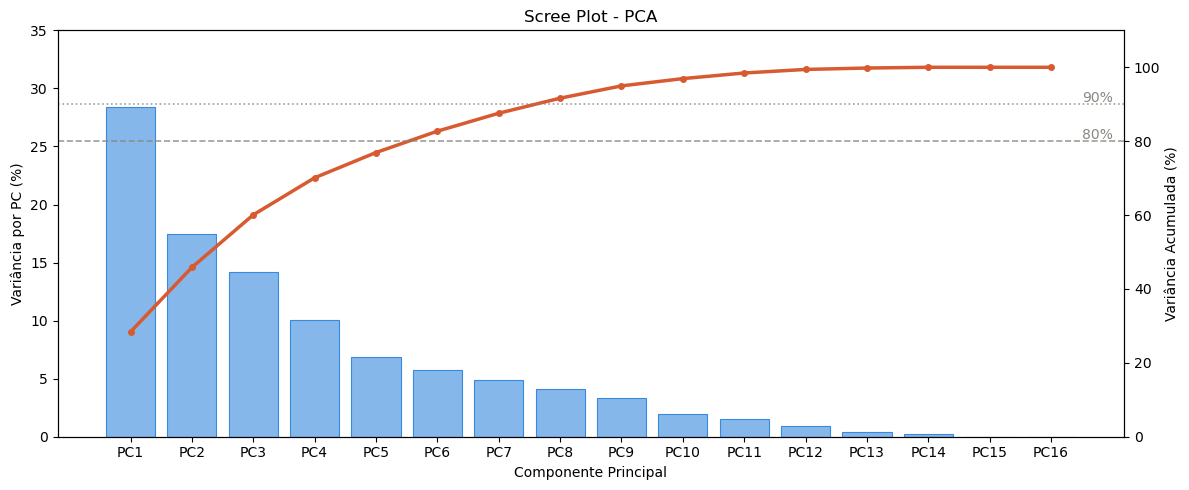


Variância por componente:
PC1: 28.4%  |  Acumulada: 28.4%
PC2: 17.5%  |  Acumulada: 45.8%
PC3: 14.2%  |  Acumulada: 60.1%
PC4: 10.0%  |  Acumulada: 70.1%
PC5: 6.8%  |  Acumulada: 76.9%
PC6: 5.8%  |  Acumulada: 82.7%
PC7: 4.9%  |  Acumulada: 87.6%
PC8: 4.1%  |  Acumulada: 91.6%
PC9: 3.3%  |  Acumulada: 95.0%
PC10: 2.0%  |  Acumulada: 96.9%
PC11: 1.5%  |  Acumulada: 98.5%
PC12: 1.0%  |  Acumulada: 99.4%
PC13: 0.4%  |  Acumulada: 99.8%
PC14: 0.2%  |  Acumulada: 100.0%
PC15: 0.0%  |  Acumulada: 100.0%
PC16: 0.0%  |  Acumulada: 100.0%


In [55]:
import matplotlib.pyplot as plt
import numpy as np

variancia = pca_model_temp.explainedVariance.toArray()
acumulada = variancia.cumsum()
labels = [f"PC{i+1}" for i in range(len(variancia))]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(labels, variancia * 100, color="#85B7EB", edgecolor="#378ADD", linewidth=0.8)
ax1.set_xlabel("Componente Principal")
ax1.set_ylabel("Variância por PC (%)")
ax1.set_ylim(0, 35)

ax2 = ax1.twinx()
ax2.plot(labels, acumulada * 100, "o-", color="#D85A30", linewidth=2.5, markersize=4)
ax2.axhline(y=80, color="#888780", linestyle="--", linewidth=1.2, alpha=0.8)
ax2.axhline(y=90, color="#888780", linestyle=":",  linewidth=1.2, alpha=0.8)
ax2.text(len(labels) - 0.5, 80.5, "80%", fontsize=10, color="#888780")
ax2.text(len(labels) - 0.5, 90.5, "90%", fontsize=10, color="#888780")
ax2.set_ylabel("Variância Acumulada (%)")
ax2.set_ylim(0, 110)

plt.title("Scree Plot - PCA")
plt.tight_layout()
plt.show()

print("\nVariância por componente:")
for i, (v, a) in enumerate(zip(variancia, acumulada)):
    print(f"PC{i+1}: {v*100:.1f}%  |  Acumulada: {a*100:.1f}%")

In [56]:
pca = PCA(k=6, inputCol="features_scaled", outputCol="pca_features")

pipeline = Pipeline(stages=[assembler, scaler, pca])

pipeline_model = pipeline.fit(df_final)

df_pca = pipeline_model.transform(df_final)

In [57]:
df_pca.select("mesorregiao", "ano", "tipo", "pca_features").show(5, truncate=False)

+-------------------------+----+----------------------+------------------------------------------------------------------------------------------------------------------------+
|mesorregiao              |ano |tipo                  |pca_features                                                                                                            |
+-------------------------+----+----------------------+------------------------------------------------------------------------------------------------------------------------+
|Agreste Paraibano (PB)   |2024|Café (em grão) Arábica|[1.1095954439049325,-0.31332725005322654,0.14656717898298588,-2.9788110175151923,-1.2552056846684558,0.9601789612244233]|
|Agreste Pernambucano (PE)|2012|Café (em grão) Arábica|[0.9516148458651391,0.1843917091659435,1.8171480255390706,-2.371709216753663,1.2844743261726874,-1.0078509204329285]    |
|Agreste Pernambucano (PE)|2013|Café (em grão) Arábica|[0.9961474763768614,0.07638557337161822,0.826408037617021,-2